# Tutorial: Injecting a synthetic glitch into detector noise

This tutorial demonstrates how to:
1. Generate a synthetic glitch using GlitchGAN
2. Create a realistic LIGO noise realisation using bilby
3. Scale the glitch to a target optimal SNR using the detector PSD
4. Inject the glitch into the noise stream
5. Compare the strain and Q-scan before and after injection

**Requirements**
```
pip install glitchgan bilby gwpy
```

---
### SNR scaling: why this matters

GlitchGAN generates normalised waveforms — the raw output has no physical amplitude.
Before injection, the glitch must be rescaled to a physically meaningful SNR.

The correct approach uses the **optimal SNR** weighted by the detector PSD $S_n(f)$:

$$\rho^2 = \frac{4}{T} \sum_f \frac{|h(f)|^2}{S_n(f)}$$

where $h(f) = \tilde{h}(f)/f_s$ is the frequency-domain strain in units of strain/Hz.
This is the SNR you get when filtering the signal against itself (template = signal),
representing the theoretical maximum.  It differs from a simple whitened-frame scaling
(which assumes $S_n = 1$ everywhere): a glitch with power concentrated at 50 Hz —
where detector noise is high — will have a much lower true SNR than a whitened
estimate would suggest.

`glitchgan.scale_for_injection` implements this correctly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bilby
from glitchgan import GlitchGAN, scale_for_injection

## 1. Generate a synthetic glitch

In [2]:
model = GlitchGAN.from_pretrained()
print(model)

/opt/homebrew/Caskroom/miniforge/base/envs/glitchgan_test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GlitchGAN(classes=['Blip', 'Fast_Scattering', 'Koi_Fish', 'Low_Frequency_Burst', 'Scattered_Light', 'Tomte', 'Whistle'], sample_rate=4096 Hz, signal_length=8192)


In [3]:
GLITCH_CLASS = "Blip"   # change to any of model.CLASSES
SAMPLE_RATE  = 4096.0   # Hz — GlitchGAN native rate
TARGET_SNR   = 30.0     # matched-filter SNR after injection

# Raw, normalised generator output — no amplitude scaling yet
glitch_raw = model.generate(GLITCH_CLASS, n=1)[0]
glitch_times = np.arange(len(glitch_raw)) / SAMPLE_RATE

print(f"Generated {GLITCH_CLASS}: {glitch_raw.shape} samples at {SAMPLE_RATE} Hz")
print(f"Duration: {len(glitch_raw)/SAMPLE_RATE:.2f} s")

Generated Blip: (8192,) samples at 4096.0 Hz
Duration: 2.00 s


## 2. Set up a bilby interferometer with Gaussian noise

We use LIGO-Hanford (H1) with its O3 design PSD to generate a realistic coloured
Gaussian noise realisation. `set_strain_data_from_power_spectral_density` draws
a noise realisation from the PSD — every call gives a different noise sample.

In [4]:
bilby.core.utils.random.seed(42)

DURATION   = 4.0    # seconds of detector data
START_TIME = 0.0    # GPS start time (arbitrary for this tutorial)

ifo = bilby.gw.detector.get_empty_interferometer("H1")
ifo.set_strain_data_from_power_spectral_density(
    sampling_frequency=SAMPLE_RATE,
    duration=DURATION,
    start_time=START_TIME,
)

print(f"Interferometer: {ifo.name}")
print(f"Strain shape:   {ifo.time_domain_strain.shape}")
print(f"PSD shape:      {ifo.power_spectral_density_array.shape}")

Interferometer: H1
Strain shape:   (16384,)
PSD shape:      (8193,)


## 3. Two injection approaches

GlitchGAN was trained on **whitened** glitches, so its raw output lives in the whitened
frame.  There are two ways to inject it into detector data:

| | Approach A | Approach B |
|---|---|---|
| Glitch frame | Whitened (GlitchGAN native) | Un-whitened → physical strain |
| Noise | Whitened bilby data | Coloured bilby data |
| Glitch scaling | Whitened-frame optimal SNR | `scale_for_injection` with PSD |

Both produce the same optimal SNR and consistent time-frequency morphology.

In [5]:
# ── Common setup ────────────────────────────────────────────────────────────
# PSD interpolated to the glitch's frequency bins (df = 0.5 Hz, 4097 bins)
glitch_freqs = np.fft.rfftfreq(len(glitch_raw), d=1.0 / SAMPLE_RATE)
psd_interp   = np.interp(glitch_freqs, ifo.frequency_array,
                          ifo.power_spectral_density_array)
# bilby sets PSD to inf/NaN at DC and below-band frequencies — zero those out
# so sqrt(psd_interp) is finite everywhere (no signal power injected at those bins)
psd_interp = np.where(np.isfinite(psd_interp) & (psd_interp > 0), psd_interp, 0.0)
# Also zero below the detector's sensitive band: the seismic wall (10–20 Hz) has
# large-but-finite PSD values that would corrupt the colouring in Approach B.
psd_interp[glitch_freqs < ifo.minimum_frequency] = 0.0

# Unit-variance normalisation: numpy irfft gives RMS = sqrt(fs/2) ≈ 45.25;
# dividing by WHITEN_NORM converts to the GWpy/GW-community convention (RMS ≈ 1).
WHITEN_NORM = np.sqrt(SAMPLE_RATE / 2)

ONSET_TIME   = START_TIME + DURATION / 2
strain_noise = ifo.time_domain_strain.copy()
n_segment    = len(ifo.time_array)
onset_sample = int((ONSET_TIME - START_TIME) * SAMPLE_RATE)

def _pad_glitch(glitch_1d, n_segment, onset_sample):
    """Zero-pad glitch_1d so its peak falls at onset_sample."""
    padded   = np.zeros(n_segment)
    peak_idx = int(np.argmax(np.abs(glitch_1d)))
    start    = onset_sample - peak_idx
    end      = start + len(glitch_1d)
    seg_s    = max(0, start)
    seg_e    = min(n_segment, end)
    src_s    = seg_s - start
    padded[seg_s:seg_e] = glitch_1d[src_s : src_s + (seg_e - seg_s)]
    return padded

### Approach A — inject in the whitened frame

The GlitchGAN output is already whitened, so we can use it directly.

1. Scale with `model.generate(..., snr=TARGET_SNR)` — this calls `_scale_snr` internally,
   which uses the flat-PSD (whitened-frame) SNR formula.
2. Whiten the bilby noise:
   $\tilde{h}_\text{white}(f) = \tilde{h}_\text{strain}(f)/\sqrt{S_n(f)}$, then IFFT.
3. Add directly — both signals are now in the same (whitened) frame.

In [6]:
# ── Approach A: whitened frame ───────────────────────────────────────────────

# 1. Scale glitch_raw to TARGET_SNR in the whitened frame
#    (same realization as Approach B — only the injection frame differs)
_g = glitch_raw.astype(np.float64)
_df = SAMPLE_RATE / len(_g)
_sigma_sq = 4.0 * _df * np.sum(np.abs(np.fft.rfft(_g) / SAMPLE_RATE) ** 2)
glitch_white_scaled = (_g * TARGET_SNR / np.sqrt(_sigma_sq)).astype(np.float32)

# 2. Whiten the bilby noise: h_white(f) = h_strain(f) / sqrt(S_n(f))
#    Divide by WHITEN_NORM for unit-variance output (RMS ≈ 1, GW community convention)
noise_white_fd     = ifo.frequency_domain_strain / np.sqrt(ifo.power_spectral_density_array)
strain_noise_white = np.fft.irfft(noise_white_fd * SAMPLE_RATE, n=n_segment) / WHITEN_NORM

# 3. Inject — both in the whitened frame
glitch_white_padded   = _pad_glitch(glitch_white_scaled / WHITEN_NORM, n_segment, onset_sample)
strain_white_injected = strain_noise_white + glitch_white_padded

print(f"Whitened noise RMS:   {np.std(strain_noise_white):.4f}  (unit-variance)")
print(f"Whitened glitch peak: {np.max(np.abs(glitch_white_padded)):.4f}  (unit-variance)")

Whitened noise RMS:   1.0000  (unit-variance)
Whitened glitch peak: 10.7547  (unit-variance)


### Approach B — inject in the strain frame

The GlitchGAN output must first be **un-whitened** to get a physical strain waveform.

1. Un-whiten: $\tilde{h}_\text{strain}(f) = \tilde{h}_\text{white}(f)\cdot\sqrt{S_n(f)}$, then IFFT.
2. Scale with `scale_for_injection` — the $S_n(f)$ from un-whitening cancels in the SNR
   formula, giving the same optimal SNR as Approach A.
3. Inject into the original coloured bilby noise.

In [7]:
# ── Approach B: strain frame ─────────────────────────────────────────────────

# 1. Un-whiten: h_strain(f) = h_white(f) * sqrt(S_n(f))
#    psd_interp has 0 at below-band bins, so those bins are zeroed out (correct)
glitch_strain = np.fft.irfft(
    np.fft.rfft(glitch_raw) * np.sqrt(psd_interp), n=len(glitch_raw)
)

# 2. Scale to target matched-filter SNR
#    Replace zero-PSD bins with a large value so they contribute ~0 to the SNR sum
psd_snr = np.where(psd_interp > 0, psd_interp, np.finfo(float).max)
glitch_scaled = scale_for_injection(
    glitch_strain, target_snr=TARGET_SNR, psd=psd_snr, sample_rate=SAMPLE_RATE
)

# 3. Inject into coloured noise
glitch_strain_padded = _pad_glitch(glitch_scaled, n_segment, onset_sample)
strain_injected      = strain_noise + glitch_strain_padded

print(f"Coloured noise RMS:   {np.std(strain_noise):.4e}  (strain)")
print(f"Strain glitch peak:   {np.max(np.abs(glitch_strain_padded)):.4e}  (strain)")

Coloured noise RMS:   2.4669e-22  (strain)
Strain glitch peak:   1.9521e-21  (strain)


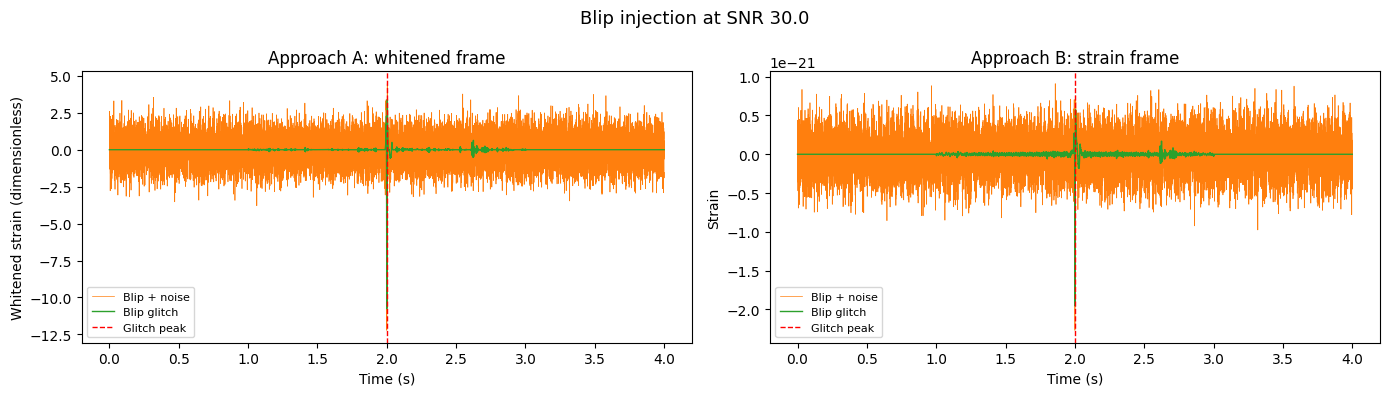

In [8]:
# ── Time-series: both approaches with glitch overlaid ────────────────────────
t = ifo.time_array - START_TIME

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Approach A: whitened frame
# axes[0].plot(t, strain_noise_white,    color="C0", lw=0.5, alpha=0.7, label="Whitened noise")
axes[0].plot(t, strain_white_injected, color="C1", lw=0.5, label=f"{GLITCH_CLASS} + noise")
axes[0].plot(t, glitch_white_padded,   color="C2", lw=1.0, label=f"{GLITCH_CLASS} glitch")
axes[0].axvline(ONSET_TIME - START_TIME, color="red", ls="--", lw=1, label="Glitch peak")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Whitened strain (dimensionless)")
axes[0].set_title("Approach A: whitened frame")
axes[0].legend(fontsize=8)

# Approach B: strain frame
# axes[1].plot(t, strain_noise,         color="C0", lw=0.5, alpha=0.7, label="Coloured noise")
axes[1].plot(t, strain_injected,      color="C1", lw=0.5, label=f"{GLITCH_CLASS} + noise")
axes[1].plot(t, glitch_strain_padded, color="C2", lw=1.0, label=f"{GLITCH_CLASS} glitch")
axes[1].axvline(ONSET_TIME - START_TIME, color="red", ls="--", lw=1, label="Glitch peak")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Strain")
axes[1].set_title("Approach B: strain frame")
axes[1].legend(fontsize=8)

fig.suptitle(f"{GLITCH_CLASS} injection at SNR {TARGET_SNR}", fontsize=13)
fig.tight_layout()
plt.show()

## 4. Q-scan comparison

`glitchgan.utils.plot_q_transform` wraps gwpy's Q-transform with consistent styling.
We plot Q-transforms for the two approaches:

- **Approach A**: whitened data.
- **Approach B**: coloured strain — If the user chooses `whiten=True`, gwpy whitens before Q-transforming. We don't whiten by default.

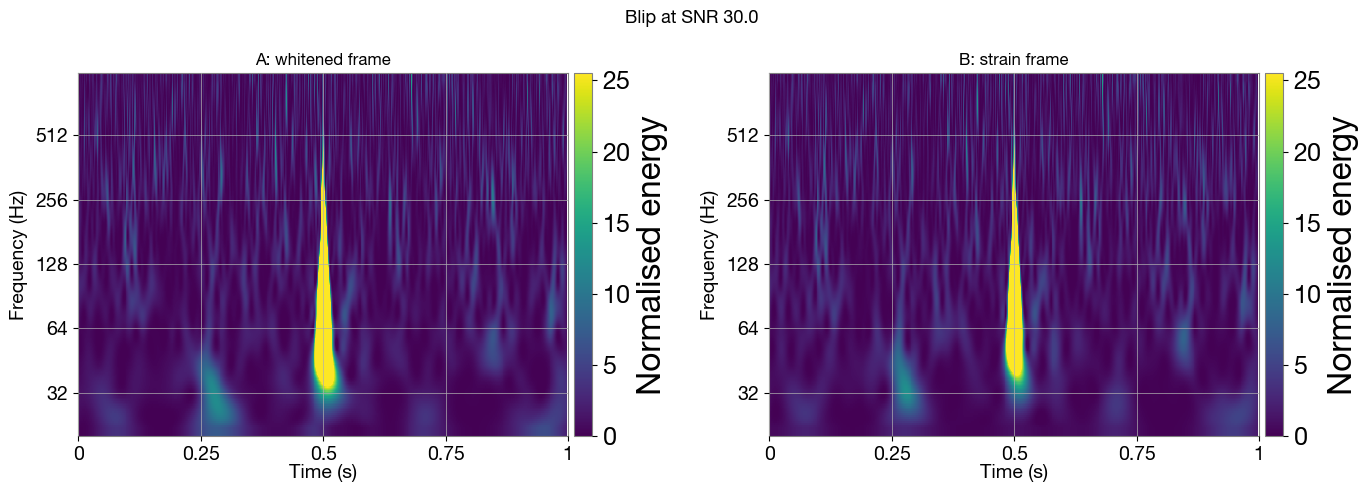

In [11]:
from glitchgan.utils import plot_q_transform

CROP    = 0.5
Q_RANGE = (4, 64)
F_RANGE = (20, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Approach A: already whitened → whiten=False
plot_q_transform(
    strain_white_injected,
    srate=SAMPLE_RATE,
    crop=(ONSET_TIME, 2 * CROP),
    whiten=False,
    qrange=Q_RANGE,
    frange=F_RANGE,
    ax=axes[0],
)
axes[0].set_title("A: whitened frame", fontsize=12)

# Approach B: coloured strain → whiten=True so gwpy normalises before Q-transforming
plot_q_transform(
    strain_injected,
    srate=SAMPLE_RATE,
    crop=(ONSET_TIME, 2 * CROP),
    whiten=False,
    qrange=Q_RANGE,
    frange=F_RANGE,
    ax=axes[1],
)
axes[1].set_title("B: strain frame", fontsize=12)

fig.suptitle(f"{GLITCH_CLASS} at SNR {TARGET_SNR}", fontsize=13)
fig.tight_layout()
plt.show()

## 5. Verify the injected SNR

Both approaches should recover `TARGET_SNR`:

- **Approach A**: $\rho^2 = (4/T)\sum_f |\tilde{h}_\text{white}(f)|^2$ (flat PSD)
- **Approach B**: $\rho^2 = (4/T)\sum_f |\tilde{h}_\text{strain}(f)|^2 / S_n(f)$ (PSD-weighted)

In [12]:
duration = len(glitch_white_scaled) / SAMPLE_RATE

# Approach A: whitened-frame optimal SNR (flat PSD — S_n = 1)
g_white_fd = np.fft.rfft(glitch_white_scaled.astype(np.float64)) / SAMPLE_RATE
snr_A = np.sqrt(np.real(4.0 / duration * np.sum(np.abs(g_white_fd) ** 2)))

# Approach B: PSD-weighted optimal SNR (exclude zero-PSD bins)
psd_snr = np.where(psd_interp > 0, psd_interp, np.finfo(float).max)
g_strain_fd = np.fft.rfft(glitch_scaled.astype(np.float64)) / SAMPLE_RATE
snr_B = np.sqrt(np.real(4.0 / duration * np.sum(np.abs(g_strain_fd) ** 2 / psd_snr)))

print(f"Target SNR:     {TARGET_SNR}")
print(f"Approach A SNR: {snr_A:.4f}  (whitened frame)")
print(f"Approach B SNR: {snr_B:.4f}  (strain frame)")

Target SNR:     30.0
Approach A SNR: 30.0000  (whitened frame)
Approach B SNR: 30.0000  (strain frame)


---
## Notes

- **Different glitch classes**: change `GLITCH_CLASS` to any of `GlitchGAN.CLASSES`.
- **Different SNR**: lower SNR values (~5–10) produce glitches that are barely visible
  in the time domain but still detectable in the Q-scan.
- **Zero noise**: replace `set_strain_data_from_power_spectral_density` with
  `set_strain_data_from_zero_noise` to see the glitch without background noise.
- **Real data**: replace the bilby noise with a real LIGO segment fetched via
  `gwpy.timeseries.TimeSeries.fetch_open_data(...)` and compute the PSD with `.psd()`.